# Experimento 14 — El modelo del experimento 13 solo con técnicas del curso

Clasificación de sentimiento de reseñas — Parte 1 (ML clásico). Aprendizaje de Máquina 2026-20, Universidad de los Andes.

Este notebook continúa `experimento13.ipynb` (modelo de dos niveles con el nivel 1 entrenado sin las reseñas de
etiqueta casi aleatoria). La sección 1 repite de forma resumida la configuración común (misma semilla, mismo split,
mismas 15 particiones de CV repetida que el experimento 13). Los experimentos anteriores **no se vuelven a ejecutar**:
sus métricas se registran como valores fijos. La única excepción es la configuración del experimento 13, que se vuelve
a medir aquí como **referencia pareada** con las mismas particiones.

**Contenido**
1. Configuración común (resumen)
2. Experimento 14 — Regresión logística en los dos niveles

## 1. Configuración común (resumen)

### 1.1 Librerías, semilla y datos

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy import stats
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     GridSearchCV, cross_val_score, cross_val_predict)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
from sklearn.base import clone

SEED = 42
np.random.seed(SEED)

CLASES = ["negativo", "neutral", "positivo"]

pd.set_option("display.max_colwidth", 200)
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})

train = pd.read_csv("train.csv").copy()
eval_df = pd.read_csv("eval.csv").copy()
sample_submission = pd.read_csv("sample_submission.csv")
conteo = train["label"].value_counts().reindex(CLASES)

print("train:", train.shape, "| eval:", eval_df.shape)

train: (12000, 3) | eval: (3000, 2)


### 1.2 Normalización base

La misma función de `experimento1.ipynb` (sección 2): reparar mojibake, minúsculas, quitar tildes conservando la ñ,
reducir letras repetidas 3+ veces a 2 y colapsar espacios. Conserva stopwords y puntuación.

In [2]:
TILDES = str.maketrans("áéíóúàèìòùäëïöüâêîôû", "aeiouaeiouaeiouaeiou")
PATRON_MOJIBAKE = re.compile(r"Ã[\x80-\xbf]")
PATRON_REPETIDAS = re.compile(r"([a-zñ])\1{2,}")


def reparar_mojibake(texto):
    return PATRON_MOJIBAKE.sub(lambda m: m.group().encode("latin-1").decode("utf-8"), texto)


def normalizar_texto(texto):
    texto = reparar_mojibake(texto)
    texto = texto.lower()
    texto = texto.translate(TILDES)
    texto = PATRON_REPETIDAS.sub(r"\1\1", texto)
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


train["text_norm"] = train["text"].map(normalizar_texto)
eval_df["text_norm"] = eval_df["text"].map(normalizar_texto)

### 1.3 Validación y métricas

Split 80/20 estratificado (el 20 % es el test hold-out, que solo se reporta). Para comparar variantes se usa **CV
repetida de 3 × 5 = 15 particiones** sobre el 80 % (como en el experimento 12): las diferencias que se buscan son de
décimas y con 5 folds quedan dentro del ruido. Todas las variantes, incluida la referencia del experimento 9, se
evalúan con **las mismas 15 particiones**. Se decide con accuracy (métrica de Kaggle).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    train["text_norm"], train["label"], test_size=0.20, stratify=train["label"], random_state=SEED
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_repetida = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
PARTICIONES = list(cv_repetida.split(X_train, y_train))
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}

print(f"Entrenamiento + validación: {len(X_train):,}  |  Test: {len(X_test):,}")

Entrenamiento + validación: 9,600  |  Test: 2,400


### 1.4 Funciones auxiliares

Las mismas de `experimento1.ipynb` (sección 3.2 y 4.3).

In [4]:
# Métricas del experimento 1 tomadas de experimento1.ipynb (no se vuelve a ejecutar aquí)
REFERENCIA_E1 = {
    "experimento": 1,
    "descripcion": "Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",
    "mejores_params": {"clf__C": 10},
    "acc_train": 0.9973,
    "acc_cv": 0.7364,
    "std_cv": 0.0128,
    "f1_cv": 0.7478,
    "acc_test": 0.7238,
    "f1_test": 0.7366,
    "envio": "submission_01.csv",
    "kaggle_publico": None,
    "acc_neg_vs_pos_test": 0.607,
}

resultados = [{k: v for k, v in REFERENCIA_E1.items() if k != "acc_neg_vs_pos_test"}]


def contiene(serie, patron):
    """Serie booleana: True si el texto contiene el patrón."""
    return serie.map(lambda t: re.search(patron, t) is not None)


def tabla_cv(busqueda):
    """Resultados de un GridSearchCV ordenados por accuracy de validación."""
    cv = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame({
        "params": cv["params"],
        "acc_train": cv["mean_train_accuracy"],
        "acc_cv": cv["mean_test_accuracy"],
        "std_cv": cv["std_test_accuracy"],
        "f1_cv": cv["mean_test_f1_macro"],
        "seg_ajuste": cv["mean_fit_time"],
    })
    return tabla.sort_values("acc_cv", ascending=False).round(4)


def evaluar_en_test(modelo, titulo):
    """Accuracy, F1 macro, reporte por clase y matriz de confusión sobre el test (hold-out)."""
    pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="macro")
    print(f"Test -> accuracy: {acc:.4f} | F1 macro: {f1:.4f}\n")
    print(classification_report(y_test, pred, labels=CLASES, digits=3))

    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASES, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión en test\n{titulo}")
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.grid(False)
    plt.show()
    return {"acc_test": acc, "f1_test": f1, "pred": pred}


def registrar_resultado(experimento, descripcion, busqueda, metricas_test, envio=None, kaggle_publico=None):
    """Agrega a la tabla de resultados el mejor modelo de un GridSearchCV."""
    i = busqueda.best_index_
    cv = busqueda.cv_results_
    resultados.append({
        "experimento": experimento,
        "descripcion": descripcion,
        "mejores_params": busqueda.best_params_,
        "acc_train": round(cv["mean_train_accuracy"][i], 4),
        "acc_cv": round(cv["mean_test_accuracy"][i], 4),
        "std_cv": round(cv["std_test_accuracy"][i], 4),
        "f1_cv": round(cv["mean_test_f1_macro"][i], 4),
        "acc_test": round(metricas_test["acc_test"], 4),
        "f1_test": round(metricas_test["f1_test"], 4),
        "envio": envio,
        "kaggle_publico": kaggle_publico,
    })
    return pd.DataFrame(resultados)


def generar_envio(busqueda, numero):
    """Reentrena la mejor configuración con las 12.000 reseñas, predice eval y guarda envío y modelo."""
    modelo = clone(busqueda.best_estimator_)
    modelo.fit(train["text_norm"], train["label"])

    envio = pd.DataFrame({"id": eval_df["id"], "answer": modelo.predict(eval_df["text_norm"])})

    assert list(envio.columns) == ["id", "answer"]
    assert len(envio) == len(sample_submission) == 3000
    assert set(envio["id"]) == set(sample_submission["id"])
    assert set(envio["answer"]) <= set(CLASES)

    Path("envios").mkdir(exist_ok=True)
    Path("modelos").mkdir(exist_ok=True)
    ruta_envio = f"envios/submission_{numero:02d}.csv"
    ruta_modelo = f"modelos/modelo_{numero:02d}.joblib"
    envio.to_csv(ruta_envio, index=False)
    joblib.dump(modelo, ruta_modelo)

    print(f"Envío guardado en {ruta_envio} y modelo en {ruta_modelo}")
    print("Distribución de predicciones en eval (%):")
    print((envio["answer"].value_counts(normalize=True).reindex(CLASES) * 100).round(1).to_string())
    return envio


def top_coeficientes(modelo, n=15):
    """N-gramas con mayor coeficiente por clase."""
    nombres = modelo.named_steps["tfidf"].get_feature_names_out()
    clf = modelo.named_steps["clf"]
    tabla = {}
    for k, clase in enumerate(clf.classes_):
        orden = clf.coef_[k].argsort()[::-1][:n]
        tabla[clase] = [f"{nombres[i]} ({clf.coef_[k][i]:.2f})" for i in orden]
    return pd.DataFrame(tabla)[CLASES]

In [5]:
# Métricas de experimentos anteriores tomadas de sus notebooks (no se vuelven a ejecutar aquí)
for fila in [
    {"experimento": 8, "descripcion": "Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",
     "acc_cv": 0.9048, "std_cv": 0.0083, "acc_test": 0.9096, "envio": "submission_08.csv", "kaggle_publico": None},
    {"experimento": 9, "descripcion": "Dos niveles con corrección de tipeo, SVM RBF (C=1)",
     "acc_train": 0.9358, "acc_cv": 0.9065, "std_cv": 0.0086, "acc_test": 0.9029, "envio": "submission_09.csv",
     "kaggle_publico": 0.91555},
    {"experimento": 13, "descripcion": "Dos niveles, nivel 1 (LinearSVC) sin reseñas evasivas, LR + interacciones (C=0,1); CV 3 × 5",
     "acc_train": 0.9343, "acc_cv": 0.9087, "std_cv": 0.0059, "acc_test": 0.9083, "envio": "submission_13.csv",
     "kaggle_publico": None},
]:
    resultados.append(fila)

ROBUSTEZ_TEST_REF = pd.DataFrame([
    {"modelo": "Exp. 9", "escenario": "Original", "accuracy": 0.9029},
    {"modelo": "Exp. 9", "escenario": "Oraciones desordenadas", "accuracy": 0.7500},
    {"modelo": "Exp. 9", "escenario": "Última oración al inicio", "accuracy": 0.6021},
    {"modelo": "Exp. 13", "escenario": "Original", "accuracy": 0.9083},
    {"modelo": "Exp. 13", "escenario": "Oraciones desordenadas", "accuracy": 0.7742},
    {"modelo": "Exp. 13", "escenario": "Última oración al inicio", "accuracy": 0.6538},
])
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,8,"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN
2,9,"Dos niveles con corrección de tipeo, SVM RBF (C=1)",NaN,0.9358,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
3,13,"Dos niveles, nivel 1 (LinearSVC) sin reseñas evasivas, LR + interacciones (C=0,1); CV 3 × 5",NaN,0.9343,0.9087,0.0059,NaN,0.9083,NaN,submission_13.csv,NaN


## 2. Experimento 14 — Regresión logística en los dos niveles

**Motivación:** el modelo del experimento 13 es el mejor según la validación interna, pero su modelo base de nivel 1 es
un **LinearSVC** (máquina de soporte vectorial lineal), que **no forma parte del programa del curso**: en el material
(sesiones 3 a 13) las SVM solo se mencionan al hablar de escalado. Todas las demás piezas del modelo sí están en el
programa:

| Pieza del modelo | Sesión del curso |
|---|---|
| Normalización de texto, TF-IDF, n-gramas, `min_df` | S04, S05 (práctica 3) |
| Distancia de edición (corrector de tipeo) | S05 (semana 2) |
| Regresión logística multiclase con regularización L2 (`C`) | S08, S09 (práctica 7) |
| `class_weight` para clases desbalanceadas (detector de opinión) | S12 (prácticas 7 y 9) |
| `StandardScaler`, interacciones con `PolynomialFeatures` | S04, S06, S07 (práctica 5) |
| Pipeline, leakage, `StratifiedKFold`, búsqueda de hiperparámetros | S04, S07 |
| Sobreajuste, sesgo-varianza, curva de aprendizaje | S06, S07, S13 |
| Accuracy, F1 macro, matriz de confusión | S10 |
| Ensembles (el stacking combina varios modelos) | S13 |

**Idea:** reemplazar el LinearSVC del nivel 1 por **regresión logística** (con su propia grilla de `C`). Con eso todos
los modelos del pipeline son regresiones logísticas: el detector de opinión, el modelo base, el modelo de polaridad y
el combinador (con interacciones de grado 2).

**Antecedentes:** en el experimento 4, con la misma representación, la regresión logística (`C = 1`) rindió
prácticamente igual que el LinearSVC en el modelo de un nivel (0,8973 frente a 0,9009). En el experimento 8,
"regresión logística en todo" quedó en ≈ 0,90, pero sin el filtro de reseñas ruidosas ni el corrector de tipeo.

**Hipótesis:** con regresión logística en el nivel 1, el modelo de dos niveles rinde igual que el del experimento 13
(diferencia dentro del ruido entre particiones).

**Proceso:**
1. Mismas definiciones y mismo filtro del experimento 13 (variante V2: el nivel 1 se entrena sin las reseñas que
   terminan en evasiva; el nivel 2 sí las ve).
2. Caché de features para el LinearSVC (referencia) y para la regresión logística con `C` ∈ {1, 3, 10}.
3. Comparar con varios combinadores lineales (regresión logística con y sin interacciones), con prueba pareada.
4. Modelo final, test, robustez, coeficientes del combinador y envío.

### 2.1 Definiciones

Las mismas funciones, el transformador `PartesE5` (`experimento5.ipynb`) y el `CorrectorTipeo` (`experimento9.ipynb`).

In [6]:
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.svm import LinearSVC

PATRON_ORACIONES = re.compile(r"(?<=[.!?;])\s+")
PATRON_CONECTOR = (
    r"\b(pero|aunque|sin embargo|aun asi|en cambio|por otro lado|al final|en fin|eso si|"
    r"no obstante|de todas formas|con todo|ahora bien)\b"
)
EVASIVAS = (
    r"^(y |aun asi,? |igual,? |en fin,? )?(cada quien|todavia no me|ni lo mejor|ni tan bueno|ni tan malo|"
    r"sigo con dudas|hay de todo|para gustos|ni |no sabria|asi que ahi|queda a criterio|lo dejo a|sopesalo|"
    r"tengo sentimientos encontrados|ahi lo dejo|ahi queda|uno termina|que cada uno|juzguen ustedes|"
    r"no se que pensar|aun no me decido|no me termino de decidir|nos quedamos con eso|no me decido)"
    r"|sigo con dudas|no me termino de decidir|sentimientos encontrados"
)
CONCLUSIVOS = r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante)\b"
CONCESIVOS = r"^(y )?(para ser|he de decir|la verdad|por cierto|de paso|por otro lado|ademas|eso si)\b"
CONECTOR_INICIAL = (
    r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|en fin|igual|ahora|no obstante|"
    r"para ser (honesto|honesta|sincero|sincera)|he de decir( que)?|la verdad( es que)?|por cierto|de paso|"
    r"por otro lado|ademas|eso si|sinceramente|para mi)\b[,:]?\s*"
)


def dividir_oraciones(texto):
    oraciones = [o.strip() for o in PATRON_ORACIONES.split(texto) if o.strip()]
    return oraciones or [texto]


def tras_ultimo_conector(texto):
    coincidencias = list(re.finditer(PATRON_CONECTOR, texto))
    return texto[coincidencias[-1].start():] if coincidencias else dividir_oraciones(texto)[-1]


def es_evasiva(oracion):
    return re.search(EVASIVAS, oracion) is not None


def sin_evasivas(texto):
    oraciones = dividir_oraciones(texto)
    return [o for o in oraciones if not es_evasiva(o)] or oraciones


def quitar_conector(oracion):
    """Elimina el conector inicial ('aun asi, ...', 'la verdad, ...') para quedarse con el contenido."""
    return re.sub(CONECTOR_INICIAL, "", oracion)


def tipo_conector(oracion):
    if re.match(CONCLUSIVOS, oracion):
        return "tipoconclusivo"
    if re.match(r"^(y )?eso si\b", oracion):
        return "tipoesosi"
    if re.match(CONCESIVOS, oracion):
        return "tipoconcesivo"
    return "tiponinguno"


def tfidf_palabras(min_df=2):
    return TfidfVectorizer(ngram_range=(1, 2), min_df=min_df, sublinear_tf=True)


class PartesE5(BaseEstimator, TransformerMixin):
    """Partes de la reseña con un detector de opinión entrenado en fit(). Variantes:

    - umbral: probabilidad mínima para considerar que una oración tiene opinión
    - quitar: quitar el conector inicial antes de pasar la oración al detector
    - pos_ultimas: agregar como ejemplos "con opinión" las últimas oraciones no evasivas de reseñas negativo/positivo
    - marcar_tipo: anteponer a la última oración con opinión un token con el tipo de su conector
    - penultima: agregar la penúltima oración con opinión como parte adicional
    """

    def __init__(self, umbral=0.5, quitar=False, pos_ultimas=False, marcar_tipo=False, penultima=False):
        self.umbral = umbral
        self.quitar = quitar
        self.pos_ultimas = pos_ultimas
        self.marcar_tipo = marcar_tipo
        self.penultima = penultima

    def _prep(self, oracion):
        return quitar_conector(oracion) if self.quitar else oracion

    def fit(self, X, y):
        con_opinion, sin_opinion = [], []
        for texto, etiqueta in zip(X, y):
            oraciones = dividir_oraciones(texto)
            if etiqueta == "neutral":
                sin_opinion.extend(oraciones)
                continue
            for oracion in oraciones:
                if (re.match(CONCLUSIVOS, oracion) or re.match(CONCESIVOS, oracion)) and not es_evasiva(oracion):
                    con_opinion.append(oracion)
            if self.pos_ultimas:
                ultima = sin_evasivas(texto)[-1]
                if len(ultima.split()) >= 6:
                    con_opinion.append(ultima)
        self.detector_ = Pipeline([
            ("tfidf", tfidf_palabras()),
            ("clf", LogisticRegression(C=1, max_iter=3000, class_weight="balanced", random_state=SEED)),
        ]).fit([self._prep(o) for o in con_opinion + sin_opinion], [1] * len(con_opinion) + [0] * len(sin_opinion))
        return self

    def opiniones(self, texto):
        """Oraciones no evasivas que el detector considera con opinión (en orden)."""
        candidatas = sin_evasivas(texto)
        prob = self.detector_.predict_proba([self._prep(o) for o in candidatas])[:, 1]
        con_opinion = [o for o, p in zip(candidatas, prob) if p >= self.umbral]
        return con_opinion or [candidatas[-1]]

    def transform(self, X):
        filas = []
        for texto in X:
            ops = self.opiniones(texto)
            ultima = ops[-1]
            fila = {
                "texto": texto,
                "ultima_op": (tipo_conector(ultima) + " " + ultima) if self.marcar_tipo else ultima,
                "tras_sin_ev": tras_ultimo_conector(" ".join(sin_evasivas(texto))),
            }
            if self.penultima:
                fila["penultima_op"] = ops[-2] if len(ops) > 1 else ""
            filas.append(fila)
        return pd.DataFrame(filas)


def pipeline_e5(clf=None, **variante):
    columnas = ["texto", "ultima_op", "tras_sin_ev"] + (["penultima_op"] if variante.get("penultima") else [])
    return Pipeline([
        ("partes", PartesE5(**variante)),
        ("tfidf", ColumnTransformer([(c, tfidf_palabras(), c) for c in columnas])),
        ("clf", clf if clf is not None else LinearSVC(C=0.2, max_iter=5000, random_state=SEED)),
    ])


y_np = y_train.to_numpy()

In [7]:
from collections import Counter

LETRAS = "abcdefghijklmnopqrstuvwxyzñ"
PATRON_PALABRA = re.compile(r"[a-zñ]+")


def ediciones_distancia_1(palabra):
    """Todas las cadenas a distancia de edición 1: borrado, transposición, sustitución e inserción."""
    cortes = [(palabra[:i], palabra[i:]) for i in range(len(palabra) + 1)]
    borrados = [a + b[1:] for a, b in cortes if b]
    transposiciones = [a + b[1] + b[0] + b[2:] for a, b in cortes if len(b) > 1]
    sustituciones = [a + c + b[1:] for a, b in cortes if b for c in LETRAS]
    inserciones = [a + c + b for a, b in cortes for c in LETRAS]
    return set(borrados + transposiciones + sustituciones + inserciones)


class CorrectorTipeo(BaseEstimator, TransformerMixin):
    """Reemplaza palabras raras por la palabra frecuente más parecida (distancia de edición 1)."""

    def __init__(self, max_rara=2, min_frecuente=15, min_largo=4):
        self.max_rara = max_rara
        self.min_frecuente = min_frecuente
        self.min_largo = min_largo

    def fit(self, X, y=None):
        self.frecuencias_ = Counter(p for texto in X for p in PATRON_PALABRA.findall(texto))
        self.frecuentes_ = {p: f for p, f in self.frecuencias_.items() if f >= self.min_frecuente}
        self.correcciones_ = {}
        for palabra, f in self.frecuencias_.items():
            if f <= self.max_rara and len(palabra) >= self.min_largo:
                candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
                if candidatas:
                    self.correcciones_[palabra] = max(candidatas, key=self.frecuentes_.get)
        return self

    def _corregir(self, palabra):
        if palabra in self.correcciones_:
            return self.correcciones_[palabra]
        if palabra not in self.frecuencias_ and len(palabra) >= self.min_largo:   # palabra nunca vista en train
            candidatas = [c for c in ediciones_distancia_1(palabra) if c in self.frecuentes_]
            if candidatas:
                return max(candidatas, key=self.frecuentes_.get)
        return palabra

    def transform(self, X):
        return [PATRON_PALABRA.sub(lambda m: self._corregir(m.group()), texto) for texto in X]

### 2.2 Grupos de reseñas ruidosas

Se definen dos grupos, solo entre reseñas `negativo`/`positivo` (para saber si una reseña es ruidosa hace falta su
etiqueta, por eso el filtro **solo puede aplicarse a datos de entrenamiento**):

| Grupo | Definición | Evidencia previa |
|---|---|---|
| `evasiva` | la última oración es una frase evasiva (lista del experimento 4) | exp. 4 y 12: ninguna parte del texto predice la etiqueta mejor que el azar |
| `secundaria` | la última oración no evasiva empieza con un conector secundario (`de paso`, `por cierto`, `por otro lado`, `ademas`) | exp. 5: si contradice a la anterior, la etiqueta sigue a cualquiera de las dos ≈ 50 % |

El grupo `secundaria` es una aproximación simple de la del experimento 5 (no exige que contradiga a la opinión
anterior, porque eso requeriría un modelo de polaridad). En el experimento 13 (sección 2.4) se verificó que **no es ruido** (78,8 % de acierto en validación), así que aquí
solo se excluye el grupo `evasiva`.

In [8]:
NOMBRES_GRUPO = ["conclusivo", "secundario", "esosi", "ninguno"]
GRUPOS = {
    "conclusivo": r"^(y )?(aun asi|al final|con todo|a fin de cuentas|sin embargo|pero|no obstante|en fin|igual|ahora)\b",
    "secundario": r"^(y )?(de paso|por cierto|por otro lado|ademas)\b",
    "esosi": r"^(y )?(eso si|la verdad)\b",
}


def grupo_conector(oracion):
    for g, patron in GRUPOS.items():
        if re.match(patron, oracion):
            return g
    return "ninguno"


def grupo_ruido(texto):
    """'evasiva', 'secundaria' o '' según cómo termina la reseña (no usa la etiqueta)."""
    if es_evasiva(dividir_oraciones(texto)[-1]):
        return "evasiva"
    if re.match(GRUPOS["secundario"], sin_evasivas(texto)[-1]):
        return "secundaria"
    return ""


def mascara_ruido(textos, etiquetas, grupos):
    """True en las reseñas negativo/positivo que pertenecen a alguno de los grupos de ruido indicados."""
    if not grupos:
        return np.zeros(len(etiquetas), dtype=bool)
    g = np.array([grupo_ruido(t) for t in textos])
    return (np.asarray(etiquetas) != "neutral") & np.isin(g, list(grupos))


GRUPO_TRAIN = np.array([grupo_ruido(t) for t in X_train])
NO_NEUTRAL = y_np != "neutral"
pd.crosstab(pd.Series(np.where(GRUPO_TRAIN == "", "resto", GRUPO_TRAIN), name="grupo"),
            pd.Series(y_np, name="etiqueta"), margins=True, margins_name="total")

etiqueta,negativo,neutral,positivo,total
grupo,,,,
evasiva,553,10,525,1088
resto,2639,2613,2631,7883
secundaria,177,238,214,629
total,3369,2861,3370,9600


### 2.3 Nivel 1 con modelo base configurable y caché de features

El mismo nivel 1 del experimento 13 (corrector → detector → TF-IDF por partes → modelo base, más el modelo de
polaridad de oraciones), con el filtro V2 fijo y un parámetro nuevo, `base`:
- `("svc", 0.2)`: LinearSVC con `C = 0,2` (experimentos 4 a 13), solo como referencia;
- `("lr", C)`: regresión logística multinomial con regularización L2 y el `C` indicado.

En los dos casos el nivel 2 recibe `decision_function` (un puntaje por clase). En la regresión logística ese puntaje
es el logit de cada clase, el valor antes de aplicar softmax (S09). Las 17 features de nivel 2 y el cross-fitting son
los mismos del experimento 13, y las particiones son las mismas 15.

In [9]:
import time

from joblib import Parallel, delayed
from sklearn.base import ClassifierMixin
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

COLUMNAS_PARTES = ["texto", "ultima_op", "tras_sin_ev"]
NOMBRES_FEATURES = (["base_negativo", "base_neutral", "base_positivo",
                     "pol_antepenultima", "pol_penultima", "pol_ultima",
                     "n_opiniones", "termina_evasiva", "ultimas_opuestas"]
                    + [f"ultima_{g}" for g in NOMBRES_GRUPO] + [f"penultima_{g}" for g in NOMBRES_GRUPO])
FILTRO = {"excluir": ("evasiva",), "donde": ("polaridad", "base")}       # variante V2 del experimento 13


def modelo_base(base):
    tipo, C = base
    if tipo == "svc":
        return LinearSVC(C=C, max_iter=5000, random_state=SEED)
    return LogisticRegression(C=C, max_iter=5000, random_state=SEED)


def fit_nivel1(X, y, base=("lr", 1), excluir=(), donde=()):
    """Nivel 1 del experimento 13 con modelo base configurable."""
    X, y = list(X), np.asarray(y)
    limpio = ~mascara_ruido(X, y, excluir)
    corrector = CorrectorTipeo().fit(X)
    X = corrector.transform(X)
    usar_base = limpio if "base" in donde else np.ones(len(y), dtype=bool)
    usar_pol = (limpio if "polaridad" in donde else np.ones(len(y), dtype=bool)) & (y != "neutral")

    X_base = [x for x, u in zip(X, usar_base) if u]
    partes = PartesE5(quitar=True).fit(X_base, y[usar_base])
    D = partes.transform(X_base)
    tfidf = ColumnTransformer([(c, tfidf_palabras(), c) for c in COLUMNAS_PARTES]).fit(D)
    clf_base = modelo_base(base).fit(tfidf.transform(D), y[usar_base])

    ultimas = [quitar_conector(partes.opiniones(t)[-1]) for t, u in zip(X, usar_pol) if u]
    polaridad = Pipeline([
        ("tfidf", tfidf_palabras()),
        ("clf", LogisticRegression(C=3, max_iter=3000, random_state=SEED)),
    ]).fit(ultimas, y[usar_pol])
    return corrector, partes, tfidf, clf_base, polaridad


def features_nivel1(X, nivel1):
    """17 features densas por reseña: puntajes del modelo base + polaridades + estructura."""
    corrector, partes, tfidf, clf_base, polaridad = nivel1
    X = corrector.transform(list(X))
    puntajes = clf_base.decision_function(tfidf.transform(partes.transform(X)))
    estructura = []
    for texto in X:
        ops = partes.opiniones(texto)
        pols = list(polaridad.decision_function([quitar_conector(o) for o in ops[-3:]]))
        pols = [0.0] * (3 - len(pols)) + pols
        g_ult = grupo_conector(ops[-1])
        g_pen = grupo_conector(ops[-2]) if len(ops) > 1 else "ninguno"
        fila = pols + [len(ops), float(es_evasiva(dividir_oraciones(texto)[-1])), float(pols[-1] * pols[-2] < 0)]
        fila += [float(g_ult == g) for g in NOMBRES_GRUPO] + [float(g_pen == g) for g in NOMBRES_GRUPO]
        estructura.append(fila)
    return np.hstack([puntajes, np.array(estructura)])


def _parte_cross_fitting(X, y, idx_tr, idx_va, config):
    return idx_va, features_nivel1([X[i] for i in idx_va], fit_nivel1([X[i] for i in idx_tr], y[idx_tr], **config))


def features_cross_fitting(X, y, config, k=5, n_jobs=1):
    """Features de nivel 2 para X calculadas con modelos de nivel 1 que no vieron cada reseña."""
    X, y = list(X), np.asarray(y)
    partes_cf = Parallel(n_jobs=n_jobs)(
        delayed(_parte_cross_fitting)(X, y, tr, va, config)
        for tr, va in StratifiedKFold(k, shuffle=True, random_state=SEED).split(X, y))
    F = np.zeros((len(X), len(NOMBRES_FEATURES)))
    for idx_va, f in partes_cf:
        F[idx_va] = f
    return F


def _particion(idx_tr, idx_va, config):
    X_tr, y_tr = list(X_train.iloc[idx_tr]), y_np[idx_tr]
    nivel1 = fit_nivel1(X_tr, y_tr, **config)
    return {
        "idx_tr": idx_tr, "idx_va": idx_va,
        "F_tr": features_cross_fitting(X_tr, y_tr, config),
        "F_tr_in": features_nivel1(X_tr, nivel1),
        "F_va": features_nivel1(list(X_train.iloc[idx_va]), nivel1),
    }


def calcular_cache(config):
    return Parallel(n_jobs=-1)(delayed(_particion)(tr, va, config) for tr, va in PARTICIONES)


VARIANTES_BASE = {
    "LinearSVC (C=0,2) [config. exp. 13]": ("svc", 0.2),
    "Regresión logística (C=1)": ("lr", 1),
    "Regresión logística (C=3)": ("lr", 3),
    "Regresión logística (C=10)": ("lr", 10),
}
CACHES = {}
for nombre, base in VARIANTES_BASE.items():
    inicio = time.time()
    CACHES[nombre] = calcular_cache({"base": base, **FILTRO})
    print(f"{nombre}: {len(PARTICIONES)} particiones en {(time.time() - inicio) / 60:.1f} min")

LinearSVC (C=0,2) [config. exp. 13]: 15 particiones en 6.9 min
Regresión logística (C=1): 15 particiones en 4.0 min
Regresión logística (C=3): 15 particiones en 2.4 min
Regresión logística (C=10): 15 particiones en 5.3 min


### 2.4 Comparación: modelo base × combinador

Cada modelo base se combina con regresiones logísticas de nivel 2:
- **sin interacciones** (`C = 1`): una combinación lineal de las 17 features, como control;
- **con interacciones de grado 2** y `C` ∈ {0,01, 0,03, 0,1, 0,3}: el combinador del experimento 13.

Igual que en el experimento 13: `acc_cv` con todas las reseñas (la métrica con la que se decide), la brecha calculada
sin las reseñas que terminan en evasiva y la diferencia pareada con la configuración del experimento 13 (LinearSVC +
LR con interacciones `C = 0,1`), con la prueba t corregida de Nadeau y Bengio sobre las 15 particiones.

In [10]:
def lr_simple(C=1):
    return Pipeline([("escala", StandardScaler()), ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED))])


def lr_interacciones(C=0.03):
    return Pipeline([
        ("escala", StandardScaler()),
        ("interacciones", PolynomialFeatures(degree=2, include_bias=False)),
        ("escala2", StandardScaler()),
        ("clf", LogisticRegression(C=C, max_iter=5000, random_state=SEED)),
    ])


RUIDO_A = NO_NEUTRAL & (GRUPO_TRAIN == "evasiva")
RESTO = NO_NEUTRAL & (GRUPO_TRAIN == "")


def _evaluar_particion(c, fabrica):
    modelo = fabrica().fit(c["F_tr"], y_np[c["idx_tr"]])
    return modelo.predict(c["F_tr_in"]), modelo.predict(c["F_va"])


def evaluar(cache, fabrica):
    preds = Parallel(n_jobs=-1)(delayed(_evaluar_particion)(c, fabrica) for c in cache)
    filas = []
    for c, (p_tr, p_va) in zip(cache, preds):
        fila = {}
        for parte, idx, p in [("train", c["idx_tr"], p_tr), ("cv", c["idx_va"], p_va)]:
            acierto = p == y_np[idx]
            fila[f"acc_{parte}"] = acierto.mean()
            fila[f"{parte}_sin_evasivas"] = acierto[~RUIDO_A[idx]].mean()
            fila[f"{parte}_resto"] = acierto[RESTO[idx]].mean()
            fila[f"{parte}_evasivas"] = acierto[RUIDO_A[idx]].mean()
        filas.append(fila)
    return pd.DataFrame(filas)


def ttest_corregido(a, b, ratio=len(PARTICIONES[0][1]) / len(PARTICIONES[0][0])):
    """Prueba t pareada corregida (Nadeau y Bengio, 2003) para CV repetida. Devuelve (diferencia media, p)."""
    d = np.asarray(a) - np.asarray(b)
    var = d.var(ddof=1)
    if var == 0:
        return d.mean(), 1.0
    t = d.mean() / np.sqrt((1 / len(d) + ratio) * var)
    return d.mean(), 2 * stats.t.sf(abs(t), len(d) - 1)


COMBINADORES = {"LR sin interacciones (C=1)": lr_simple,
                **{f"LR + interacciones (C={C})": (lambda C=C: lr_interacciones(C)) for C in [0.01, 0.03, 0.1, 0.3]}}
EVAL = {(b, comb): evaluar(CACHES[b], f) for b in VARIANTES_BASE for comb, f in COMBINADORES.items()}
REF_E13 = EVAL[("LinearSVC (C=0,2) [config. exp. 13]", "LR + interacciones (C=0.1)")]

filas = []
for (b, comb), r in EVAL.items():
    delta, p = ttest_corregido(r["acc_cv"], REF_E13["acc_cv"])
    filas.append({
        "modelo base": b, "combinador": comb,
        "acc_cv": r["acc_cv"].mean(), "std_cv": r["acc_cv"].std(ddof=0), "acc_train": r["acc_train"].mean(),
        "brecha_sin_evasivas": 100 * (r["train_sin_evasivas"] - r["cv_sin_evasivas"]).mean(),
        "cv | neg/pos resto": r["cv_resto"].mean(), "cv | evasivas": r["cv_evasivas"].mean(),
        "Δ vs exp. 13 (puntos)": 100 * delta, "p": p,
        "particiones que gana al exp. 13": int((r["acc_cv"].to_numpy() > REF_E13["acc_cv"].to_numpy()).sum()),
    })
tabla = pd.DataFrame(filas).sort_values("acc_cv", ascending=False)
tabla.round(4)

,modelo base,combinador,acc_cv,std_cv,acc_train,brecha_sin_evasivas,cv | neg/pos resto,cv | evasivas,Δ vs exp. 13 (puntos),p,particiones que gana al exp. 13
3,"LinearSVC (C=0,2) [config. exp. 13]",LR + interacciones (C=0.1),0.9088,0.0057,0.9343,2.4771,0.9500,0.5164,0.0000,1.0000,0
4,"LinearSVC (C=0,2) [config. exp. 13]",LR + interacciones (C=0.3),0.9085,0.0057,0.9349,2.5300,0.9500,0.5157,-0.0278,0.7777,6
2,"LinearSVC (C=0,2) [config. exp. 13]",LR + interacciones (C=0.03),0.9085,0.0073,0.9325,2.3410,0.9500,0.5145,-0.0312,0.8341,8
1,"LinearSVC (C=0,2) [config. exp. 13]",LR + interacciones (C=0.01),0.9081,0.0072,0.9300,2.1260,0.9498,0.5114,-0.0764,0.6102,5
8,Regresión logística (C=1),LR + interacciones (C=0.1),0.9055,0.0069,0.9280,2.1692,0.9456,0.5136,-0.3368,0.0421,2
9,Regresión logística (C=1),LR + interacciones (C=0.3),0.9053,0.0072,0.9288,2.2602,0.9454,0.5145,-0.3472,0.0849,3
7,Regresión logística (C=1),LR + interacciones (C=0.03),0.9050,0.0065,0.9262,2.0384,0.9452,0.5117,-0.3785,0.0305,0
0,"LinearSVC (C=0,2) [config. exp. 13]",LR sin interacciones (C=1),0.9047,0.0075,0.9357,3.4605,0.9451,0.5072,-0.4167,0.2140,3
13,Regresión logística (C=3),LR + interacciones (C=0.1),0.9046,0.0065,0.9382,3.3507,0.9458,0.5039,-0.4236,0.0187,1
12,Regresión logística (C=3),LR + interacciones (C=0.03),0.9044,0.0073,0.9360,3.1438,0.9457,0.5024,-0.4375,0.0052,0


In [11]:
# Resumen: mejor combinador para cada modelo base
resumen = tabla.loc[tabla.groupby("modelo base")["acc_cv"].idxmax()].sort_values("acc_cv", ascending=False)
resumen[["modelo base", "combinador", "acc_cv", "std_cv", "brecha_sin_evasivas", "Δ vs exp. 13 (puntos)", "p"]].round(4)

,modelo base,combinador,acc_cv,std_cv,brecha_sin_evasivas,Δ vs exp. 13 (puntos),p
3,"LinearSVC (C=0,2) [config. exp. 13]",LR + interacciones (C=0.1),0.9088,0.0057,2.4771,0.0000,1.0000
8,Regresión logística (C=1),LR + interacciones (C=0.1),0.9055,0.0069,2.1692,-0.3368,0.0421
13,Regresión logística (C=3),LR + interacciones (C=0.1),0.9046,0.0065,3.3507,-0.4236,0.0187
16,Regresión logística (C=10),LR + interacciones (C=0.01),0.9042,0.0073,3.4419,-0.4653,0.0159


**Lectura**

- **La referencia se reproduce:** LinearSVC + LR con interacciones (`C = 0,1`) da 0,9088 en estas 15 particiones,
  igual que en el experimento 13 (0,9087).
- **Con regresión logística en el nivel 1, el modelo pierde ≈ 0,3 puntos.** La mejor configuración (`C = 1` en el
  nivel 1, LR con interacciones `C = 0,1` en el nivel 2) llega a **0,9055 ± 0,0069**: −0,34 puntos frente al
  experimento 13, con p = 0,04, y gana solo en 2 de las 15 particiones. A diferencia de las comparaciones anteriores,
  esta diferencia **sí es estadísticamente significativa** (al 5 %), aunque pequeña (≈ 8 reseñas de 2.400).
- **De dónde viene la pérdida:** en las reseñas predecibles (`cv | neg/pos resto`) baja de 0,950 a 0,946. Los puntajes
  del LinearSVC separan un poco mejor `negativo` de `positivo` que los logits de la regresión logística con la misma
  representación. La pérdida ya se había visto en el experimento 4 (−0,36 puntos en el modelo de un nivel) y se
  traslada casi igual al de dos niveles.
- **El `C` del nivel 1 importa:** `C = 1` es el mejor (0,9055). Con `C = 3` o `C = 10` la regresión logística sobreajusta
  más (brecha sin evasivas de 2,7–4,7 puntos frente a 2,0–2,3 con `C = 1`) y rinde peor. Es el mismo óptimo del experimento 4.
- **Las interacciones sí aportan:** sin interacciones, la regresión logística de nivel 2 queda entre 0,9007 y 0,9047.
  Con interacciones de grado 2 gana entre 0,1 y 0,5 puntos según el modelo base (+0,48 con el elegido). Es la misma conclusión del
  experimento 8: lo que el combinador aprende son **interacciones** (por ejemplo, polaridad de la última opinión ×
  tipo de conector), y con un modelo lineal hay que dárselas como features (S07).
- **En contexto:** 0,9055 es lo mismo que la configuración del experimento 9 medida en estas mismas particiones
  (0,9049 en el experimento 13), el modelo con el mejor score público. Usar solo técnicas del curso cuesta lo que
  aportó el filtro del experimento 13, no más.

### 2.5 Modelo del experimento 14

Se elige, **solo entre las configuraciones con regresión logística en el nivel 1**, la de mayor accuracy de CV. La
clase `DosNivelesE14` es la `DosNivelesE13` con el parámetro `base`: el filtro se aplica al nivel 1 (dentro del
cross-fitting y en el reentrenamiento final) y el nivel 2 se entrena con todas las reseñas.

In [12]:
solo_lr = tabla[tabla["modelo base"].str.startswith("Regresión logística")]
elegida = solo_lr.iloc[0]
BASE = VARIANTES_BASE[elegida["modelo base"]]
COMBINADOR = elegida["combinador"]
print(f"Modelo base: {elegida['modelo base']} | combinador: {COMBINADOR} | CV = {elegida['acc_cv']:.4f} ± {elegida['std_cv']:.4f}")


class DosNivelesE14(BaseEstimator, ClassifierMixin):
    """Stacking del experimento 13 con modelo base configurable (regresión logística en todos los niveles)."""

    def __init__(self, base=("lr", 1), excluir=("evasiva",), donde=("polaridad", "base"), nivel2=None, n_jobs=5):
        self.base = base
        self.excluir = excluir
        self.donde = donde
        self.nivel2 = nivel2
        self.n_jobs = n_jobs

    def fit(self, X, y):
        X, y = list(X), np.asarray(y)
        config = {"base": self.base, "excluir": self.excluir, "donde": self.donde}
        F = features_cross_fitting(X, y, config, n_jobs=self.n_jobs)
        self.nivel1_ = fit_nivel1(X, y, **config)
        self.nivel2_ = clone(self.nivel2).fit(F, y)
        self.classes_ = self.nivel2_.classes_
        return self

    def predict(self, X):
        return self.nivel2_.predict(features_nivel1(list(X), self.nivel1_))


modelo_e14 = DosNivelesE14(base=BASE, nivel2=COMBINADORES[COMBINADOR]()).fit(X_train, y_train)
acierto_train = modelo_e14.predict(X_train) == y_np
print(f"Accuracy de entrenamiento: {acierto_train.mean():.4f} "
      f"(sin evasivas: {acierto_train[~RUIDO_A].mean():.4f} | evasivas: {acierto_train[RUIDO_A].mean():.4f})")

Modelo base: Regresión logística (C=1) | combinador: LR + interacciones (C=0.1) | CV = 0.9055 ± 0.0069
Accuracy de entrenamiento: 0.9261 (sin evasivas: 0.9748 | evasivas: 0.5417)


Test -> accuracy: 0.9113 | F1 macro: 0.9156

              precision    recall  f1-score   support

    negativo      0.868     0.886     0.877       843
     neutral      0.997     0.997     0.997       715
    positivo      0.882     0.863     0.873       842

    accuracy                          0.911      2400
   macro avg      0.916     0.916     0.916      2400
weighted avg      0.911     0.911     0.911      2400



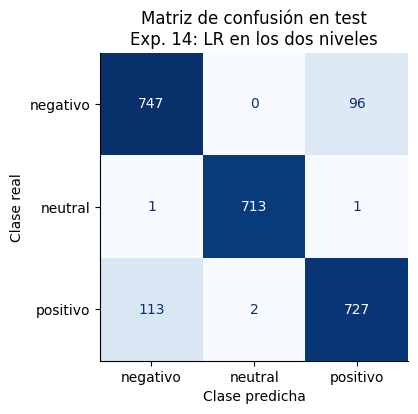

Negativo vs positivo en test: 0.875
  neg/pos evasiva    ( 285): 0.519
  neg/pos secundaria ( 101): 0.842
  neg/pos resto      (1299): 0.955


In [13]:
metricas_e14 = evaluar_en_test(modelo_e14, f"Exp. 14: LR en los dos niveles")
grupo_test = np.array([grupo_ruido(t) for t in X_test])
y_t, pred = y_test.to_numpy(), metricas_e14["pred"]
np_test = y_t != "neutral"
print(f"Negativo vs positivo en test: {(pred[np_test] == y_t[np_test]).mean():.3f}")
for nombre, m in [("evasiva", np_test & (grupo_test == "evasiva")), ("secundaria", np_test & (grupo_test == "secundaria")),
                  ("resto", np_test & (grupo_test == ""))]:
    print(f"  neg/pos {nombre:<10} ({m.sum():>4}): {(pred[m] == y_t[m]).mean():.3f}")

### 2.6 Prueba de robustez en test

In [14]:
def desordenar_oraciones(textos, seed=SEED):
    rng = np.random.default_rng(seed)
    salida = []
    for texto in textos:
        oraciones = dividir_oraciones(texto)
        salida.append(" ".join(rng.permutation(oraciones)) if len(oraciones) > 1 else texto)
    return pd.Series(salida, index=textos.index)


def ultima_al_inicio(textos):
    def mover(texto):
        oraciones = dividir_oraciones(texto)
        return " ".join([oraciones[-1]] + oraciones[:-1])
    return textos.map(mover)


ESCENARIOS = {
    "Original": X_test,
    "Oraciones desordenadas": desordenar_oraciones(X_test),
    "Última oración al inicio": ultima_al_inicio(X_test),
}
filas = [{"modelo": "Exp. 14", "escenario": e, "accuracy": accuracy_score(y_test, modelo_e14.predict(X_e))}
         for e, X_e in ESCENARIOS.items()]
robustez = pd.concat([ROBUSTEZ_TEST_REF, pd.DataFrame(filas)], ignore_index=True)
robustez.pivot(index="escenario", columns="modelo", values="accuracy").reindex(list(ESCENARIOS)).round(4)

modelo,Exp. 13,Exp. 14,Exp. 9
escenario,,,
Original,0.9083,0.9112,0.9029
Oraciones desordenadas,0.7742,0.7746,0.7500
Última oración al inicio,0.6538,0.6525,0.6021


### 2.7 Coeficientes del combinador

Una ventaja de tener regresión logística en el nivel 2 es que sus coeficientes se pueden leer (S09): para cada clase,
las features (y productos de dos features) que más la empujan hacia arriba o hacia abajo. Como las features están
estandarizadas, los coeficientes son comparables entre sí.

In [15]:
comb = modelo_e14.nivel2_
nombres = (comb.named_steps["interacciones"].get_feature_names_out(NOMBRES_FEATURES)
           if "interacciones" in comb.named_steps else np.array(NOMBRES_FEATURES))
coef = comb.named_steps["clf"].coef_
clases = list(comb.classes_)
tabla_coef = {}
for clase in ["negativo", "positivo"]:
    w = coef[clases.index(clase)]
    orden = np.argsort(w)
    tabla_coef[f"{clase} (+)"] = [f"{nombres[j]} ({w[j]:+.2f})" for j in orden[::-1][:10]]
    tabla_coef[f"{clase} (−)"] = [f"{nombres[j]} ({w[j]:+.2f})" for j in orden[:10]]
pd.DataFrame(tabla_coef)

,negativo (+),negativo (−),positivo (+),positivo (−)
0,base_negativo (+1.20),base_negativo n_opiniones (-0.56),base_positivo (+1.04),base_negativo (-0.58)
1,n_opiniones (+0.30),pol_ultima (-0.53),pol_ultima (+0.51),base_positivo n_opiniones (-0.50)
2,base_neutral base_positivo (+0.28),base_neutral (-0.50),base_neutral ultimas_opuestas (+0.32),base_positivo ultimas_opuestas (-0.34)
3,base_neutral n_opiniones (+0.27),base_positivo (-0.39),base_negativo n_opiniones (+0.29),base_neutral (-0.26)
4,pol_ultima^2 (+0.21),base_positivo^2 (-0.29),pol_ultima ultima_conclusivo (+0.26),base_positivo termina_evasiva (-0.16)
5,pol_ultima ultimas_opuestas (+0.18),pol_ultima ultima_conclusivo (-0.25),base_positivo^2 (+0.23),base_negativo pol_ultima (-0.16)
6,base_positivo termina_evasiva (+0.17),base_negativo termina_evasiva (-0.20),ultimas_opuestas^2 (+0.21),pol_ultima ultimas_opuestas (-0.15)
7,base_positivo n_opiniones (+0.16),base_neutral^2 (-0.19),ultimas_opuestas (+0.21),pol_ultima ultima_secundario (-0.15)
8,pol_ultima ultima_ninguno (+0.16),base_negativo base_positivo (-0.18),pol_ultima^2 (+0.18),base_negativo pol_penultima (-0.14)
9,pol_antepenultima penultima_conclusivo (+0.16),base_neutral pol_ultima (-0.13),base_neutral pol_penultima (+0.14),pol_penultima penultima_secundario (-0.14)


**Lectura** (coeficientes con features estandarizadas; "a × b" es el producto de dos features)

- **El puntaje del modelo base es la señal principal:** `base_negativo` (+1,20 para `negativo`) y `base_positivo`
  (+1,04 para `positivo`) son los coeficientes más grandes. Le sigue la **polaridad de la última opinión**
  (`pol_ultima`: +0,51 para `positivo`, −0,53 para `negativo`).
- **El combinador aprendió cuándo desconfiar del modelo base:**
  - `base_negativo × n_opiniones` (−0,56 para `negativo`) y `base_positivo × n_opiniones` (−0,50 para `positivo`):
    cuantas más opiniones tiene la reseña, menos peso recibe el puntaje del modelo base;
  - `base_positivo × ultimas_opuestas` (−0,34 para `positivo`): si las dos últimas opiniones tienen signos opuestos,
    también;
  - `base_negativo × termina_evasiva` (−0,20) y `base_positivo × termina_evasiva` (−0,16): si la reseña termina en
    evasiva, el puntaje del modelo base pesa menos (en esas reseñas la etiqueta es casi aleatoria).
- **El tipo de conector modula la polaridad:** `pol_ultima × ultima_conclusivo` (+0,26 para `positivo`, −0,25 para
  `negativo`) indica que la polaridad de la última opinión pesa **más** cuando empieza con un conector conclusivo
  (`aun asi`, `al final`...), y `pol_ultima × ultima_secundario` (−0,15 para `positivo`) que pesa **menos** cuando
  empieza con un conector secundario (`por cierto`, `de paso`). Son las reglas del análisis de errores de los
  experimentos 4 y 5, aprendidas aquí directamente de los datos.
- Estas reglas son las mismas que se leyeron en el experimento 8. Es la ventaja de un combinador lineal con
  interacciones frente a un SVM RBF o un modelo de boosting: lo que aprende se puede explicar en la sustentación.

### 2.8 Registro y envío

In [16]:
from types import SimpleNamespace

r_final = EVAL[(elegida["modelo base"], COMBINADOR)]
resultados.append({
    "experimento": 14,
    "descripcion": f"Dos niveles con LR en todo: base {elegida['modelo base']}, {COMBINADOR}; nivel 1 sin evasivas; CV 3 × 5",
    "acc_train": round(r_final["acc_train"].mean(), 4),
    "acc_cv": round(r_final["acc_cv"].mean(), 4),
    "std_cv": round(r_final["acc_cv"].std(ddof=0), 4),
    "acc_test": round(metricas_e14["acc_test"], 4),
    "f1_test": round(metricas_e14["f1_test"], 4),
    "envio": "submission_14.csv",
    "kaggle_publico": None,
})
pd.DataFrame(resultados)

,experimento,descripcion,mejores_params,acc_train,acc_cv,std_cv,f1_cv,acc_test,f1_test,envio,kaggle_publico
0,1,"Línea base: TF-IDF (1,2), min_df=2, sublinear + LR (ajuste de C)",{'clf__C': 10},0.9973,0.7364,0.0128,0.7478,0.7238,0.7366,submission_01.csv,NaN
1,8,"Dos niveles: LinearSVC + polaridad por oración -> LR + interacciones grado 2 (C=0,03)",NaN,NaN,0.9048,0.0083,NaN,0.9096,NaN,submission_08.csv,NaN
2,9,"Dos niveles con corrección de tipeo, SVM RBF (C=1)",NaN,0.9358,0.9065,0.0086,NaN,0.9029,NaN,submission_09.csv,0.91555
3,13,"Dos niveles, nivel 1 (LinearSVC) sin reseñas evasivas, LR + interacciones (C=0,1); CV 3 × 5",NaN,0.9343,0.9087,0.0059,NaN,0.9083,NaN,submission_13.csv,NaN
4,14,"Dos niveles con LR en todo: base Regresión logística (C=1), LR + interacciones (C=0.1); nivel 1 sin evasivas; CV 3 × 5",NaN,0.9280,0.9055,0.0069,NaN,0.9113,0.9156,submission_14.csv,NaN


In [17]:
envio_e14 = generar_envio(SimpleNamespace(best_estimator_=modelo_e14), numero=14)

for n in [9, 13]:
    anterior = pd.read_csv(f"envios/submission_{n:02d}.csv")
    print(f"Predicciones iguales a submission_{n:02d}.csv: {(anterior['answer'] == envio_e14['answer']).mean():.1%}")

Envío guardado en envios/submission_14.csv y modelo en modelos/modelo_14.joblib
Distribución de predicciones en eval (%):
answer
negativo    36.2
neutral     27.6
positivo    36.1
Predicciones iguales a submission_09.csv: 95.3%
Predicciones iguales a submission_13.csv: 97.9%


### 2.9 Análisis del experimento 14

**Resultados:** modelo de dos niveles con **regresión logística en todos los componentes**: detector de opinión,
modelo base (`C = 1`), modelo de polaridad y combinador con interacciones de grado 2 (`C = 0,1`). El nivel 1 se entrena
sin las reseñas que terminan en evasiva. CV 3 × 5 = **0,9055 ± 0,0069**; test = **0,9113** (F1 macro 0,916).

| | Exp. 9 | Exp. 13 | **Exp. 14** |
|---|---|---|---|
| Modelo base del nivel 1 | LinearSVC | LinearSVC | **Regresión logística** |
| Combinador | SVM RBF | LR + interacciones | LR + interacciones |
| ¿Todo dentro del programa del curso? | No (SVM) | No (LinearSVC) | **Sí** |
| Accuracy CV (mismas 15 particiones) | 0,9049 | **0,9088** | 0,9055 |
| Accuracy test | 0,9029 | 0,9083 | **0,9113** |
| Test, oraciones desordenadas | 0,750 | 0,774 | **0,775** |
| Test, última oración al inicio | 0,602 | **0,654** | 0,653 |
| Kaggle público | **0,91555** | pendiente | pendiente |

1. **La hipótesis no se confirma del todo.** Con regresión logística en el nivel 1, el modelo queda 0,34 puntos por
   debajo del experimento 13, una diferencia pequeña pero estadísticamente significativa (p = 0,04). La causa es la
   misma del experimento 4: con esta representación, los puntajes del LinearSVC separan un poco mejor
   `negativo`/`positivo` que los de la regresión logística.
2. **Frente al modelo con mejor score público (exp. 9) es un empate:** 0,9055 frente a 0,9049 en las mismas
   particiones. Usar solo técnicas del curso no cuesta nada respecto al modelo final actual; solo deja de ganar lo
   que aportó el filtro del experimento 13.
3. **En test es el mejor de los tres** (0,9113), pero la diferencia con el exp. 13 (+0,3 puntos, ≈ 7 reseñas) está
   dentro del error estándar del test (≈ 0,006) y va en sentido contrario a la CV. Según la regla del proyecto, **se
   decide con la CV**; el test solo indica que no hay señales de sobreajuste.
4. **Robustez igual que el exp. 13** (0,775 / 0,653), la mejor del proyecto entre los modelos de dos niveles.
5. **Es el modelo más fácil de sustentar:** cada pieza está en el programa (tabla de la sección 2) y los coeficientes
   del combinador se pueden leer como reglas (sección 2.7).
6. **En eval coincide en un 97,9 % con `submission_13`** y en un 95,3 % con `submission_09`.

**Límites:** igual que en el experimento 13 (filtro basado en una lista de evasivas hecha a mano, dependencia de la
posición del veredicto, meseta de ≈ 0,905–0,909).

**Decisión:** se genera `submission_14.csv`. La elección final depende de qué pida el curso:
- **Si solo se permiten técnicas vistas en clase**, el experimento 14 es el modelo a entregar: rinde igual que el
  experimento 9 en validación, es el más robusto y todas sus piezas se pueden justificar con el material.
- **Si se permiten técnicas adicionales**, el experimento 13 sigue siendo el mejor según la CV (+0,34 puntos).
- En los dos casos, el enunciado pide entregar el modelo del **mejor score público**: hay que subir `submission_13` y
  `submission_14` a Kaggle y comparar con el 0,91555 del experimento 9, sabiendo que diferencias de menos de ≈ 1 punto
  en el leaderboard público son sobre todo ruido.